# Desarrollo del Ejercicio 1: Uso de Algoritmos de Búsqueda

In [16]:
from P1_MazeLoader import MazeLoader
import matplotlib.pyplot as plt

## A) Leer el laberinto y presentarlo como un grafo

### Cargar laberinto
El archivo P1_MazeLoader.py, contiene ya funciones para la carga de los laberintos de archivos .txt
- Celda disponible para caminar = ' '
- Entrada = 'E'
- Salida = 'S'
- Muro o pared = '#'

In [17]:
maze = MazeLoader('laberinto1.txt').load_Maze()
maze.maze

Loading Maze from C:\Users\DETPC\Ex-Python\IA_class\Semana1\_Soluciones\Grupo4\Taller2\P1\laberinto1.txt


[['#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#'],
 ['#', 'E', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '#'],
 ['#', ' ', '#', '#', '#', ' ', '#', '#', '#', ' ', '#'],
 ['#', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '#'],
 ['#', '#', '#', ' ', '#', ' ', '#', ' ', '#', '#', '#'],
 ['#', ' ', ' ', ' ', '#', ' ', '#', ' ', ' ', ' ', '#'],
 ['#', ' ', '#', '#', '#', ' ', '#', '#', '#', ' ', '#'],
 ['#', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'S', '#'],
 ['#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#']]

## Graficar laberinto
La funcion plot_maze() utiliza matplotlib y los colores definidos en P1.util, para dibujar los laberintos

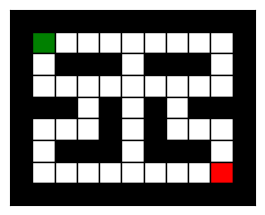

In [18]:
maze.plot_maze()

## Grafo

In [19]:
graph = maze.get_graph()
len(graph)

43

La funcion get_graph() convierte el laberinto en un grafo, donde cada celda libre (' ', 'E', 'S') es un nodo.

Luego conecta cada nodo con sus vecinos válidos (arriba, abajo, izquierda o derecha), creando así las adyacencias para poder aplicar algoritmos de búsqueda

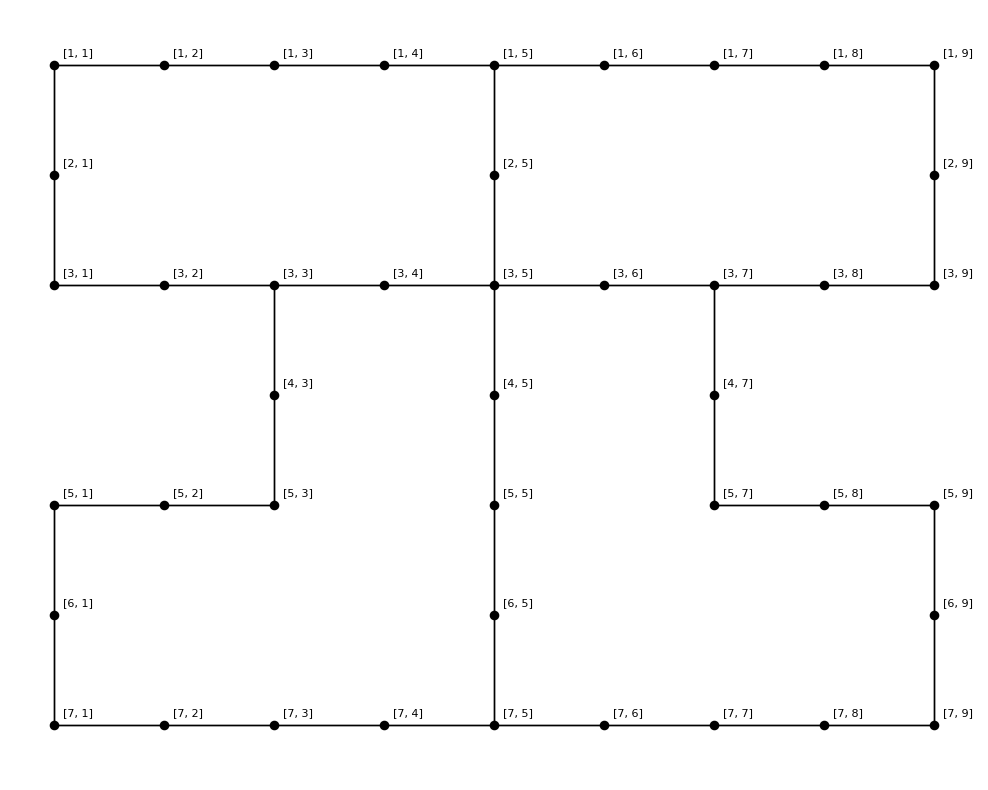

In [20]:
maze.plot_graph(graph)

## BFS

El algoritmo BFS (búsqueda en anchura) empieza desde la entrada 'E' y explora el laberinto usando una cola, visitando primero los nodos más cercanos.

Va guardando los nodos visitados y un diccionario parents para recordar de dónde viene cada nodo. En cada iteración, toma un nodo de la cola y revisa sus vecinos no visitados, agregándolos a la cola.

Cuando encuentra la salida 'S', reconstruye el camino usando parents, mide el tiempo (se utiliza luego para comparar las soluciones) y muestra la solución.

Si no hubiera un camino, indicaría que no hay solución.

**path_bfs**: muestra el camino solución que encontro el algoritmo, el cual luego se utiliza para pintar de color celeste los bloques que conforman la solución.

BFS: tiempo 0.0882 ms, pasos 14


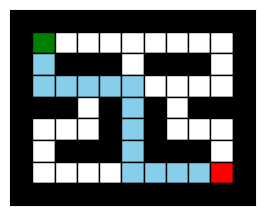

[(1, 1),
 (2, 1),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (4, 5),
 (5, 5),
 (6, 5),
 (7, 5),
 (7, 6),
 (7, 7),
 (7, 8),
 (7, 9)]

In [21]:
path_bfs = maze.solve_bfs(graph)
path_bfs

## DFS

Este algoritmo es una búsqueda en profundidad (DFS), ya que usa una pila en lugar de una cola.

Empieza desde 'E' y va explorando un camino hasta el fondo antes de retroceder, guardando los nodos visitados y sus parents. En cada iteración, toma el último nodo agregado y revisa sus vecinos.

Cuando encuentra la salida 'S', reconstruye el camino, mide el tiempo y muestra la solución.

A diferencia de BFS, no garantiza encontrar el camino más corto, puede ser mas beneficioso sin no existe mucha profundidad en el laberinto

DFS: tiempo 0.1339 ms, pasos 34


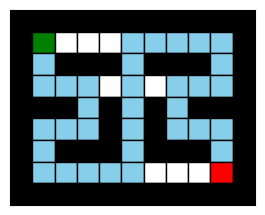

[(1, 1),
 (2, 1),
 (3, 1),
 (3, 2),
 (3, 3),
 (4, 3),
 (5, 3),
 (5, 2),
 (5, 1),
 (6, 1),
 (7, 1),
 (7, 2),
 (7, 3),
 (7, 4),
 (7, 5),
 (6, 5),
 (5, 5),
 (4, 5),
 (3, 5),
 (2, 5),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (2, 9),
 (3, 9),
 (3, 8),
 (3, 7),
 (4, 7),
 (5, 7),
 (5, 8),
 (5, 9),
 (6, 9),
 (7, 9)]

In [22]:
path_dfs = maze.solve_dfs(graph)
path_dfs

## A*

Este código implementa el algoritmo A*, que busca el camino más corto usando una combinación de costo real y heurística.

Utiliza una cola de prioridad donde los nodos se ordenan según *costo acumulado + distancia Manhattan* hacia la meta. Se requiere actualizar los costos y guardar los padres para reconstruir el camino.

En cada iteración, se selecciona el nodo más prometedor y explora a sus vecinos, evitando caminos más costosos.

Cuando llega a 'S', reconstruye la ruta óptima, mide el tiempo y muestra la solución; si no, indicaría que no encontró camino.

A*: tiempo 0.1070 ms, pasos 14


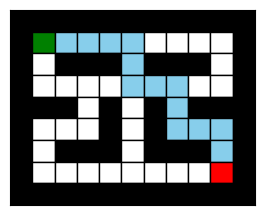

[(1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (2, 5),
 (3, 5),
 (3, 6),
 (3, 7),
 (4, 7),
 (5, 7),
 (5, 8),
 (5, 9),
 (6, 9),
 (7, 9)]

In [23]:
path_astar = maze.solve_astar(graph)
path_astar

## Nota:
Mas detalle se presenta en el Readme, pero igualmente aqui se responde a la pregunta:

*  ¿Se puede establecer alguna métrica para evaluar los algoritmos en este problema*

**Evaluación de algoritmos**

Para evaluar el desempeño de los algoritmos de búsqueda en la resolución de laberintos, se pueden utilizar métricas mencionadas en la literatura previa.

La métrica más utilizada es el tiempo de ejecución, generalmente expresado en milisegundos o segundos, dependiendo de la complejidad del problema (Cruz-Ruiz et al., 2019; Molina Vargas et al., 2008). Esta métrica permite comparar la eficiencia computacional de cada algoritmo.
Adicionalmente, existen otras métricas relevantes (Gabrovsek, 2019):

Número de pasos de la solución: mide la longitud del camino encontrado.
Número de nodos explorados: indica el costo de exploración del algoritmo.
Número de intersecciones visitadas: refleja la complejidad del recorrido.
Número de callejones sin salida explorados: permite evaluar la eficiencia en la toma de decisiones.

Si bien estas métricas, en conjunto, permiten realizar una evaluación más completa del rendimiento de cada algoritmo, en este caso se utilizaron dos, las cuales se muestran en la Tabla.

| Algoritmo | **Laberinto 1**  |  | **Laberinto 2** |  | **Laberinto 3** |  |
|-----------|------------------|--|-----------------|--|-----------------|--|
|           | Tiempo ejecución | Pasos | Tiempo ejecución | Pasos | Tiempo ejecución         | Pasos |
| BFS       | 0,0373 ms        | 14 | 0,1089 ms       | 44 | 0,4018 ms       | 344 |
| DFS       | 0,0357 ms        | 34 | 0,1034 ms       | 44 | 0,6882 ms       | 378 |
| A*        | 0,0859 ms        | 14 | 0,1868 ms       | 44 | 0,9499 ms       | 344 |

Al comparar los algoritmos en los tres laberintos, se observaron los siguientes comportamientos entre eficiencia (tiempo) y calidad (número de pasos).

- En laberinto1, el algoritmo DFS presenta el menor tiempo de ejecución, sin embargo, su solución requiere un mayor número de pasos (34 frente a 14 de BFS y A*). Esto indica que es rápido pero no óptimo. Por otro lado, BFS y A* encuentran la mejor solución (menor número de pasos), aunque con mayor tiempo computacional en el caso de A*.

- En laberinto2, todos los algoritmos encuentran soluciones con el mismo número de pasos (44). En este caso, DFS vuelve a ser el más rápido, seguido de BFS, mientras que A* resulta el más lento, probablemente debido a la heurística.

- En laberinto3, que es el más complejo, se mantiene la tendencia: DFS es el más rápido, pero nuevamente produce una solución con más pasos. BFS y A* encuentran soluciones óptimas (344 pasos), siendo BFS más eficiente en tiempo que A*.

En conclusión, para estos tres casos particulares, BFS ofrece un buen balance entre eficiencia y calidad, A* garantiza soluciones similares a BFS pero con mayor costo computacional, y DFS fue veloz pero tiene mala calidad de solución.
